In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Input
from tensorflow.keras.layers import Dropout  
from tensorflow.keras.callbacks import EarlyStopping 

from sklearn.model_selection import train_test_split 
from sklearn.datasets import make_circles 

import warnings 

from pylab import rcParams 

from mlxtend.plotting import plot_decision_regions 
from matplotlib.colors import ListedColormap

In [3]:
x,y = make_circles(
    n_samples=100, 
    noise=0.1,
    random_state=42
) 

<Axes: >

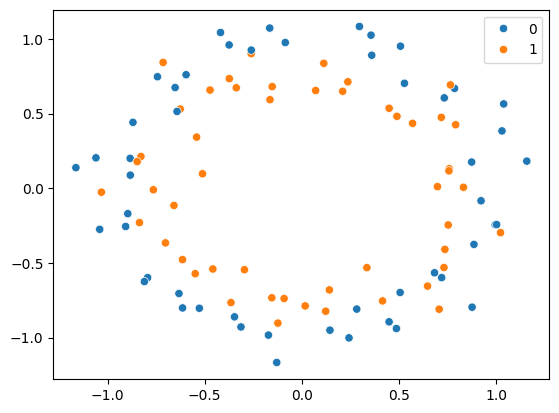

In [5]:
sns.scatterplot(x = x[:,0],y = x[:,1],hue=y)

In [6]:
x_train , x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
model = Sequential([
    Input(shape=(2,)), 
    Dense(256, activation='relu'), 
    Dense(1, activation='sigmoid')
])

In [10]:
model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam', 
    metrics = ['accuracy']
)

In [12]:
history = model.fit(x_train,
                   y_train,
                   validation_data=(x_test, y_test),
                   epochs = 500 , 
                   verbose = 0 )

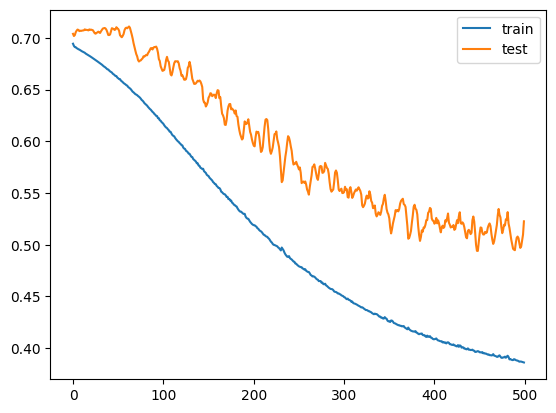

In [13]:
# loss graph 

plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'], label ='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step


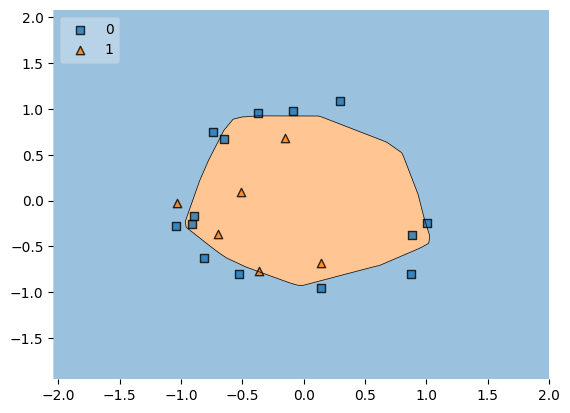

In [17]:
# Decision boundary 
plot_decision_regions(x_test, y_test.ravel(), clf= model, legend=2)
plt.show()

## Early Stopping

In [19]:
model = Sequential([
    Input(shape=(2,)),
    Dense(256 , activation='relu'), 
    Dense(1 , activation='sigmoid')
])

In [20]:
model.compile(
    loss = 'binary_crossentropy', 
    optimizer = 'adam' , 
    metrics = ['accuracy']
)

In [26]:
# IMP 
calls = EarlyStopping(
    monitor="val_loss", 
    min_delta=0.00001, 
    patience= 30 ,
    verbose= 1 ,
    mode="auto" , 
    baseline= None , 
    restore_best_weights= False
)

In [27]:
history = model.fit(x_train,
                    y_train,
                    validation_data=(x_test, y_test),
                    epochs=3500,
                    callbacks=calls)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6250 - loss: 0.6790 - val_accuracy: 0.4500 - val_loss: 0.7080
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.6250 - loss: 0.6785 - val_accuracy: 0.4500 - val_loss: 0.7070
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6250 - loss: 0.6776 - val_accuracy: 0.4500 - val_loss: 0.7078
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6375 - loss: 0.6773 - val_accuracy: 0.4500 - val_loss: 0.7090
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.6500 - loss: 0.6768 - val_accuracy: 0.4000 - val_loss: 0.7109
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6375 - loss: 0.6757 - val_accuracy: 0.4000 - val_loss: 0.7128
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6375 - loss: 0.6754 - val_accuracy: 0.4000 - val_loss: 0.7155
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6375 - loss: 0.6748 - val_accuracy: 0.

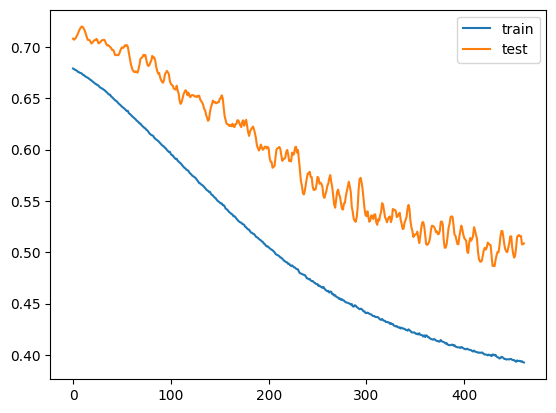

In [28]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step


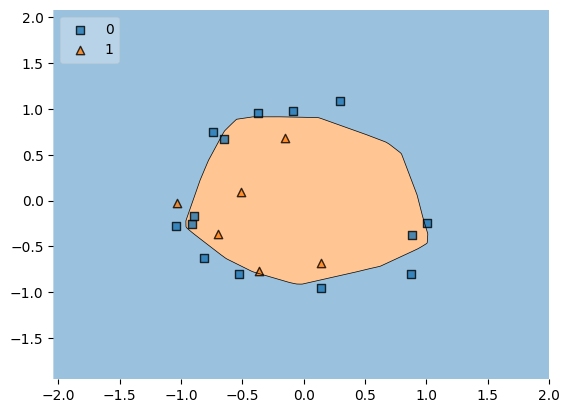

In [29]:
plot_decision_regions(x_test, y_test.ravel(), clf = model, legend=2)
plt.show()